# Part 4 — Classification:

**Goal:** build models that predict whether a customer will churn (`1` = Attrited Customer, `0` = Existing Customer).

**Requirements covered in this notebook**
1. `train_test_split` with `stratify=y`
2. At least 3 classifiers + `DummyClassifier(strategy='stratified')` as a baseline
3. Accuracy, Precision, Recall, F1-score and ROC AUC for every model
4. Confusion matrices
5. Model comparison and documented final model selection

**Important:** the engineered dataset contains only the scaled features, not the target. We reload the target from the original Kaggle data and check that the rows line up.

## Step 1 — Import libraries
We import pandas/numpy for data handling, matplotlib/seaborn for charts, and scikit-learn for splitting, modelling and metrics.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)

RANDOM_STATE = 42   # fixed seed so everyone in the team gets identical results
sns.set_style("whitegrid")

## Step 2 — Load the engineered, scaled features
`DATA_PATH` is the file (dataset).  We expect **10,127 rows** and **35 numeric columns**.

In [7]:
DATA_PATH = ("/content/Engineered_Scaled_Data(1).csv..txt")

X = pd.read_csv(DATA_PATH)
print("Shape:", X.shape)
print("Missing values:", X.isna().sum().sum())
print("All columns numeric:", all(np.issubdtype(t, np.number) for t in X.dtypes))
X.head()

Shape: (10127, 35)
Missing values: 0
All columns numeric: True


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,-0.165406,0.503368,0.384621,0.763943,-1.327136,0.492404,0.446622,-0.473422,0.488971,2.623494,...,-0.798507,-0.282609,-0.463363,2.494645,-0.422675,-0.736437,-0.351212,-0.107644,-0.044484,-0.240794
1,0.333570,2.043199,1.010715,1.407306,-1.327136,-0.411616,-0.041367,-0.366667,-0.008486,3.563293,...,1.252337,-0.282609,-0.463363,-0.400859,-0.422675,1.357890,-0.351212,-0.107644,-0.044484,-0.240794
2,0.583058,0.503368,0.008965,0.120579,-1.327136,-2.219655,-0.573698,-1.426858,-0.445658,8.367214,...,-0.798507,-0.282609,-0.463363,-0.400859,2.365881,-0.736437,-0.351212,-0.107644,-0.044484,-0.240794
3,-0.789126,1.273283,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,1.661686,-0.734100,2.942843,...,-0.798507,3.538459,-0.463363,-0.400859,-0.422675,1.357890,-0.351212,-0.107644,-0.044484,-0.240794
4,-0.789126,0.503368,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,-1.426858,-0.302868,6.455682,...,-0.798507,-0.282609,-0.463363,2.494645,-0.422675,-0.736437,-0.351212,-0.107644,-0.044484,-0.240794


## Step 3 — Load the target (`y`) from the original Kaggle dataset
The scaled file has **no churn column**, so we take `Attrition_Flag` from the raw data via `kagglehub` and convert it to 0/1:
- `Attrited Customer` → **1** (churned, the class we care about)
- `Existing Customer` → **0**

The raw file is only read, never modified.

In [8]:
import kagglehub, os

path = kagglehub.dataset_download("sakshigoyal7/credit-card-customers")
raw = pd.read_csv(os.path.join(path, "BankChurners.csv"))

y = (raw["Attrition_Flag"] == "Attrited Customer").astype(int)
y.name = "Churn"

print("Raw shape:", raw.shape, "| Features shape:", X.shape)
assert len(raw) == len(X), "Row counts differ - X and y cannot be matched!"

100%|██████████| 379k/379k [00:00<00:00, 73.7MB/s]

Extracting files...
Raw shape: (10127, 23) | Features shape: (10127, 35)


### Step 3b — Safety check: are the rows still in the same order?
`X` was scaled, but scaling is a straight-line transformation, so a scaled column must be almost perfectly correlated (≈ 1.0) with the same raw column **if row order is unchanged**. If the correlations are not ≈ 1, then rows were shuffled/dropped in Part 2 and `y` would be wrongly matched.

In [9]:
for col in ["Customer_Age", "Total_Trans_Ct", "Credit_Limit"]:
    r = np.corrcoef(X[col], raw[col])[0, 1]
    print(f"{col:16s} correlation with raw column: {r:.4f}")
    assert r > 0.999, f"Rows look misaligned for {col}!"
print("Alignment check passed.")

Customer_Age     correlation with raw column: 1.0000
Total_Trans_Ct   correlation with raw column: 1.0000
Credit_Limit     correlation with raw column: 1.0000
Alignment check passed.


## Step 4 — Check the class balance
Churners are the minority class. This is why accuracy alone can mislead, and why we stratify the split. (Here we train on the data as it is.)

Churn
0    8500
1    1627
Name: count, dtype: int64

Churn rate: 16.07%


/tmp/ipykernel_1192/2629123092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_1192/2629123092.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Existing (0)", "Churned (1)"])


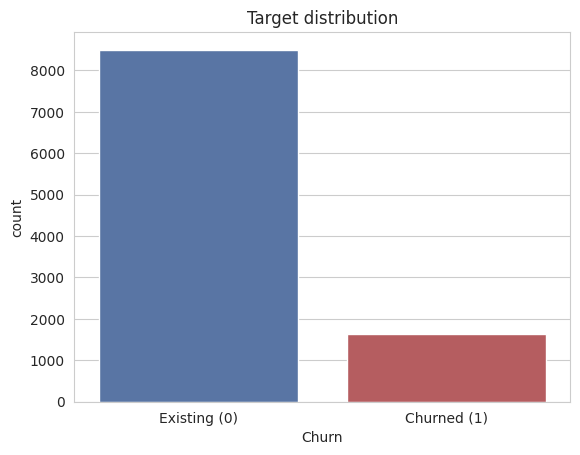

In [10]:
counts = y.value_counts()
print(counts)
print("\nChurn rate: {:.2%}".format(y.mean()))

ax = sns.countplot(x=y, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Existing (0)", "Churned (1)"])
ax.set_title("Target distribution")
plt.show()

## Step 5 — Stratified train/test split
- `test_size=0.20`: 80% to learn from, 20% kept unseen for honest evaluation.
- `stratify=y`: both sets keep the same churn percentage as the full data. Without it, the small churn class could be unevenly split.
- `random_state=42`: makes the split reproducible.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn rate  full: {:.3%} | train: {:.3%} | test: {:.3%}".format(
      y.mean(), y_train.mean(), y_test.mean()))

Train: (8101, 35) | Test: (2026, 35)
Churn rate  full: 16.066% | train: 16.072% | test: 16.041%


## Step 6 — Build a reusable evaluation function
Every model goes through the same steps so the comparison is fair:
1. Fit on the **training** data.
2. Predict classes and churn probabilities on the **test** data.
3. Calculate the five metrics for the churn class (`1`):
   - **Accuracy** – share of all predictions that are right.
   - **Precision** – of customers predicted to churn, how many really did.
   - **Recall** – of customers who really churned, how many we caught.
   - **F1-score** – balance between precision and recall.
   - **ROC AUC** – how well the model ranks churners above non-churners (0.5 = random, 1.0 = perfect).

In [12]:
results = []          # metric rows for the comparison table
fitted_models = {}    # keep trained models for later plots
predictions = {}      # keep predictions for confusion matrices / ROC curves

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]      # probability of churn

    row = {
        "Model": name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
        "ROC AUC":   roc_auc_score(y_test, y_proba),
    }
    results.append(row)
    fitted_models[name] = model
    predictions[name] = (y_pred, y_proba)

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Existing", "Churned"], zero_division=0))
    return row

## Step 7 — Baseline: `DummyClassifier(strategy='stratified')`
This model ignores the features and guesses randomly while matching the training class proportions. It shows the score to beat: any real model must do clearly better, otherwise it has learned nothing.

In [13]:
evaluate_model("Dummy (stratified)",
               DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))

--- Dummy (stratified) ---
              precision    recall  f1-score   support

    Existing       0.84      0.84      0.84      1701
     Churned       0.17      0.17      0.17       325

    accuracy                           0.73      2026
   macro avg       0.51      0.51      0.51      2026
weighted avg       0.73      0.73      0.73      2026



{'Model': 'Dummy (stratified)',
 'Accuracy': 0.7324777887462981,
 'Precision': 0.1702127659574468,
 'Recall': 0.1723076923076923,
 'F1-score': 0.1712538226299694,
 'ROC AUC': np.float64(0.5059069325735992)}

## Step 8 — Model 1: Logistic Regression
A simple, fast linear model that is easy to interpret. It works well on scaled data (which we have). `max_iter=1000` gives it enough iterations to converge.

In [14]:
evaluate_model("Logistic Regression",
               LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Existing       0.93      0.97      0.95      1701
     Churned       0.81      0.61      0.70       325

    accuracy                           0.91      2026
   macro avg       0.87      0.79      0.82      2026
weighted avg       0.91      0.91      0.91      2026



{'Model': 'Logistic Regression',
 'Accuracy': 0.9146100691016782,
 'Precision': 0.8089430894308943,
 'Recall': 0.6123076923076923,
 'F1-score': 0.6970227670753065,
 'ROC AUC': np.float64(0.9418513996291773)}

## Step 9 — Model 2: Random Forest
Many decision trees voting together. It captures non-linear patterns and interactions between features and is fairly robust to overfitting.

In [15]:
evaluate_model("Random Forest",
               RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))

--- Random Forest ---
              precision    recall  f1-score   support

    Existing       0.96      0.99      0.98      1701
     Churned       0.95      0.79      0.86       325

    accuracy                           0.96      2026
   macro avg       0.95      0.89      0.92      2026
weighted avg       0.96      0.96      0.96      2026



{'Model': 'Random Forest',
 'Accuracy': 0.9595261599210266,
 'Precision': 0.945054945054945,
 'Recall': 0.7938461538461539,
 'F1-score': 0.862876254180602,
 'ROC AUC': np.float64(0.9865870754759642)}

## Step 10 — Model 3: Gradient Boosting
Builds trees one after another, each correcting the errors of the previous ones. It is often the strongest model on tabular data like this.

In [16]:
evaluate_model("Gradient Boosting",
               GradientBoostingClassifier(random_state=RANDOM_STATE))

--- Gradient Boosting ---
              precision    recall  f1-score   support

    Existing       0.97      0.99      0.98      1701
     Churned       0.95      0.82      0.88       325

    accuracy                           0.96      2026
   macro avg       0.96      0.90      0.93      2026
weighted avg       0.96      0.96      0.96      2026



{'Model': 'Gradient Boosting',
 'Accuracy': 0.9639684106614018,
 'Precision': 0.9532374100719424,
 'Recall': 0.8153846153846154,
 'F1-score': 0.87893864013267,
 'ROC AUC': np.float64(0.9878659611992945)}

## Step 11 — Confusion matrices
A confusion matrix shows the counts of correct and wrong predictions:
- **Top-left (TN):** existing customers correctly predicted as staying.
- **Bottom-right (TP):** churners correctly caught.
- **Top-right (FP):** loyal customers wrongly flagged as churners (wasted retention effort).
- **Bottom-left (FN):** churners we **missed** (lost customers) — usually the costliest error.

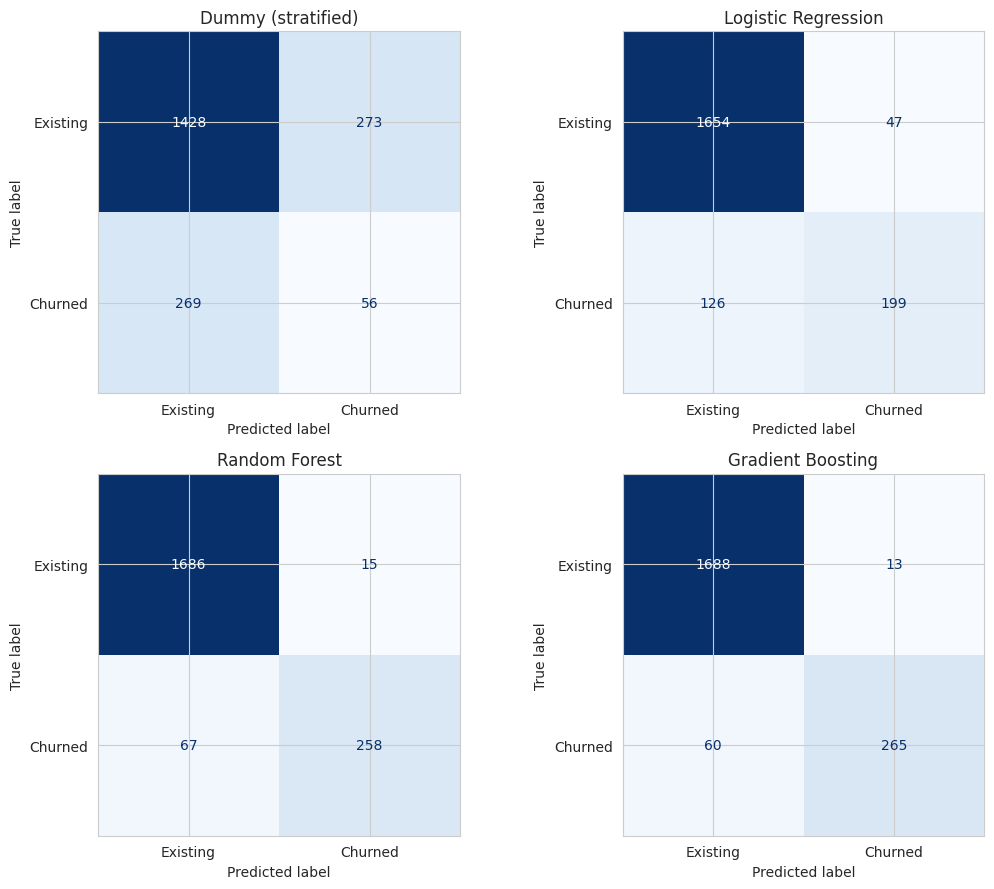

In [17]:
names = list(predictions.keys())
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, name in zip(axes.ravel(), names):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Existing", "Churned"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [18]:
for name, (y_pred, _) in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"{name:22s}TN={tn} FP={fp} FN={fn} TP={tp}")

Dummy (stratified)    TN=1428 FP=273 FN=269 TP=56
Logistic Regression   TN=1654 FP=47 FN=126 TP=199
Random Forest         TN=1686 FP=15 FN=67 TP=258
Gradient Boosting     TN=1688 FP=13 FN=60 TP=265


In [19]:
y_pred, _ = predictions["Gradient Boosting"]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Missed churners (FN):", fn)
print("False alarms (FP):", fp)

Missed churners (FN): 60
False alarms (FP): 13


## Step 12 — Compare all models
The table collects the five metrics side by side, sorted by F1-score (a better summary than accuracy when classes are imbalanced).

In [20]:
results_df = (pd.DataFrame(results)
                .set_index("Model")
                .sort_values("F1-score", ascending=False)
                .round(4))
results_df

,Accuracy,Precision,Recall,F1-score,ROC AUC
Model,,,,,
Gradient Boosting,0.9640,0.9532,0.8154,0.8789,0.9879
Random Forest,0.9595,0.9451,0.7938,0.8629,0.9866
Logistic Regression,0.9146,0.8089,0.6123,0.6970,0.9419
Dummy (stratified),0.7325,0.1702,0.1723,0.1713,0.5059


### ROC curves
Each curve shows the trade-off between catching churners (true positive rate) and false alarms (false positive rate) at every threshold. The closer to the top-left corner, the better; the dashed diagonal is random guessing.

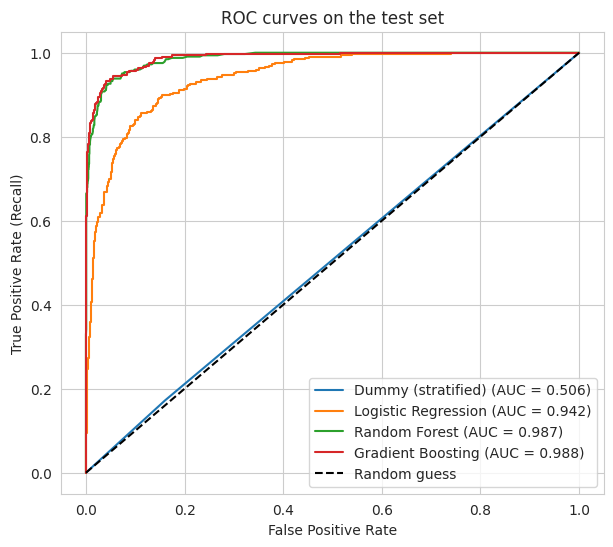

In [21]:
plt.figure(figsize=(7, 6))
for name, (_, y_proba) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC curves on the test set")
plt.legend(loc="lower right")
plt.show()

### Metric comparison chart

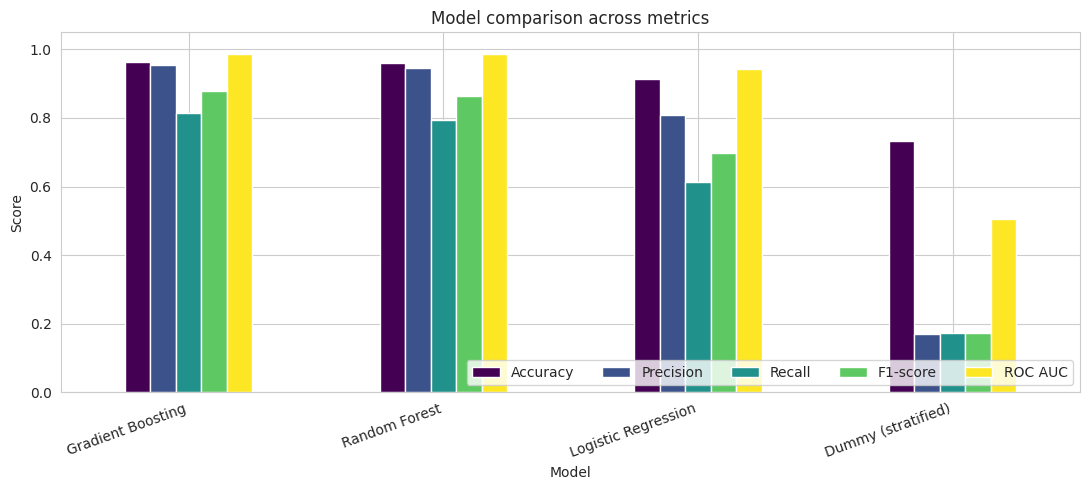

In [22]:
results_df.plot(kind="bar", figsize=(11, 5), colormap="viridis")
plt.title("Model comparison across metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="lower right", ncol=5)
plt.tight_layout()
plt.show()

## Step 13 — Cross-validation check (is the result stable?)
A single split can be lucky or unlucky. Here each real model is scored with 5-fold stratified cross-validation **on the training data only** (the test set stays untouched). A small spread means the model performs consistently.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, model in fitted_models.items():
    if name.startswith("Dummy"):
        continue
    f1_cv  = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    auc_cv = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_rows.append({"Model": name,
                    "CV F1 mean": f1_cv.mean(), "CV F1 std": f1_cv.std(),
                    "CV ROC AUC mean": auc_cv.mean(), "CV ROC AUC std": auc_cv.std()})

pd.DataFrame(cv_rows).set_index("Model").round(4)

,CV F1 mean,CV F1 std,CV ROC AUC mean,CV ROC AUC std
Model,,,,
Logistic Regression,0.7150,0.0099,0.9398,0.0043
Random Forest,0.8547,0.0257,0.9885,0.0027
Gradient Boosting,0.8828,0.0187,0.9898,0.0020


## Step 14 — Which features drive the best model?
For tree-based models, feature importance shows which columns the model relied on most. This links the model back to business meaning.

Best model by F1-score: Gradient Boosting


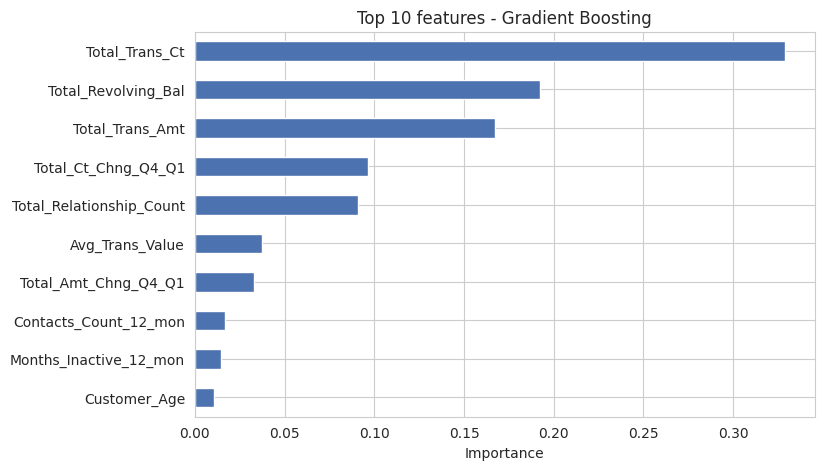

In [24]:
best_name = results_df.index[0]
print("Best model by F1-score:", best_name)

best_model = fitted_models[best_name]
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    imp[::-1].plot(kind="barh", figsize=(8, 5), color="#4C72B0")
    plt.title(f"Top 10 features - {best_name}")
    plt.xlabel("Importance")
    plt.show()
else:
    coefs = pd.Series(best_model.coef_[0], index=X.columns)
    coefs.reindex(coefs.abs().sort_values(ascending=False).head(10).index)[::-1].plot(
        kind="barh", figsize=(8, 5), color="#4C72B0")
    plt.title(f"Top 10 coefficients - {best_name}")
    plt.show()

## Step 15 — Final model selection

**1. Baseline check.** The Dummy classifier reached F1 = 0.1713 and ROC AUC = 0.5059 (about 0.5). Every real model beat it clearly, so the features carry real signal.

**2. Accuracy is misleading here.** About 83.93% of customers stay, so a model that always says "no churn" already scores 83.93% accuracy while catching no churners. That is why we judged models on Recall, F1 and ROC AUC.

**3. Model comparison.** GradientBoostijng performed best, with an F1-scoreof 0.8789, recall of 0.8154, precision of 0.9532 and ROC AUC of 0.9879. Random Forest was a close second (F1 0.8629, Recall 0.7938, Precision 0.9451, ROC AUC 0.9866).

Logistic Regression was clearly weaker (F1 0.6970, Recall 0.6123), suggesting churn depends on non-linear patterns that a linear model cannot capture. All three beat the dummy baseline (F1 0.1713, ROC AUC 0.5059).

**4. Errors.** The best model(Gradient Boosting) missed  60 churners (false negatives) and wrongly flagged 13 loyal customers (false positives). For the bank a missed churner is the worst error because that customer leaves without any chance to be retained, and loosing a customer costs more than aretenhtion offer. A false alarm only wastes a small retention effort on someone who would have stayed anyway. False negatives are the costlier mistake, Recall is the metric the  bank should watch most closely.

**5. Stability.** Cross-validation gave F1 = 0.8828 ± 0.0187, close to the test result, so the model is not just lucky on one split.

**6. Final choice. Gradient Boosting.** It achieved the highest F1-score (0.8789), the best Recall (0.8154), and the highest ROC AUC (0.9879) of all the models, and beat the Dummy baseline by a wide margin. It was also stable in cross-validation (F1 O.0187), so the result is not a lucky split. Its feature importance is easy to explain to the business: the strongest predictors are Total_Train_Ct, Total_Revolving_Bal and Total_Trans_Amt, which shows that customers who transact less and carry lower balances are most likely to churn.

